In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [111]:
df = pd.read_csv("data__movies.csv", sep=",")
df

,budget,genres,homepage,id,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count
0,237000000,"Action, Adventure, Fantasy, Science Fiction",http://www.avatarmovie.com/,19995,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"Adventure, Fantasy, Action",http://disney.go.com/disneypictures/pirates/,285,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"Action, Adventure, Crime",http://www.sonypictures.com/movies/spectre/,206647,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"Action, Crime, Drama, Thriller",http://www.thedarkknightrises.com/,49026,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"Action, Adventure, Science Fiction",http://movies.disney.com/john-carter,49529,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,2124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"Action, Crime, Thriller",NaN,9367,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,Columbia Pictures,1992-09-04,2040920,81.0,Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238
4799,9000,"Comedy, Romance",NaN,72766,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,NaN,2011-12-26,0,85.0,Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5
4800,0,"Comedy, Drama, Romance, TV Movie",http://www.hallmarkchannel.com/signedsealeddel...,231617,en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"Front Street Pictures, Muse Entertainment Ente...",2013-10-13,0,120.0,Released,NaN,"Signed, Sealed, Delivered",7.0,6
4801,0,NaN,http://shanghaicalling.com/,126186,en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,NaN,2012-05-03,0,98.0,Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7


## Análisis exploratorio inicial — justificación visual de la limpieza

Antes de aplicar cualquier transformación, exploramos el CSV crudo para **justificar empíricamente** cada decisión de limpieza posterior:

1. **Nulos por columna** → decide qué columnas eliminar y dónde imputar.
2. **Distribución de variables numéricas** crudas → muestra el sesgo y la presencia de ceros sospechosos (datos faltantes encubiertos), que justifican los filtros `> 0` y la transformación `log`.
3. **Frecuencia de categóricas** (productoras, géneros, idiomas) → justifica los recortes a top 10 / top 8 (las categorías raras tienen muy pocos datos para estimar coeficientes confiables).

Cada gráfico tiene una nota al pie indicando qué decisión de limpieza posterior justifica.

CSV crudo: 4,803 filas × 17 columnas



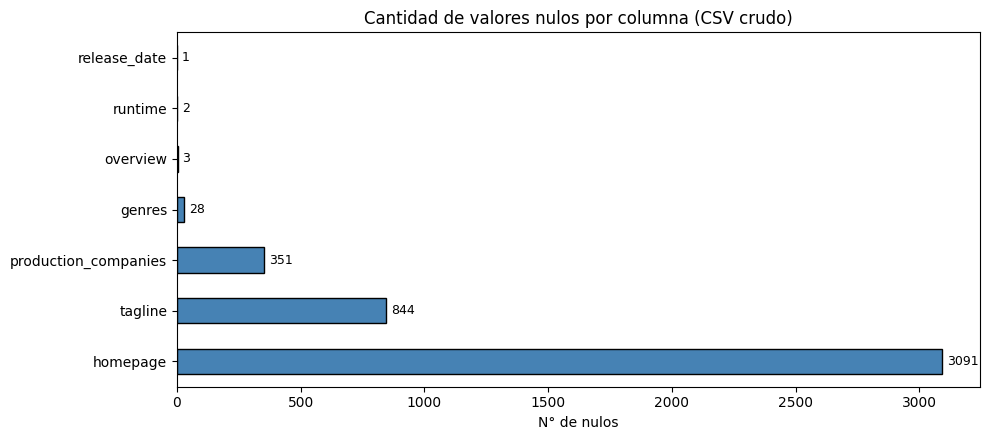

→ Decisiones que justifica este gráfico:
  • 'homepage' (3091 nulos) y 'tagline' (~840) se eliminan por demasiados faltantes.
  • 'production_companies' y 'genres' tienen pocos nulos: imputamos con 'otros'/'desconocido'.
  • 'release_date' y 'runtime' tienen muy pocos nulos: dropeamos esas filas.



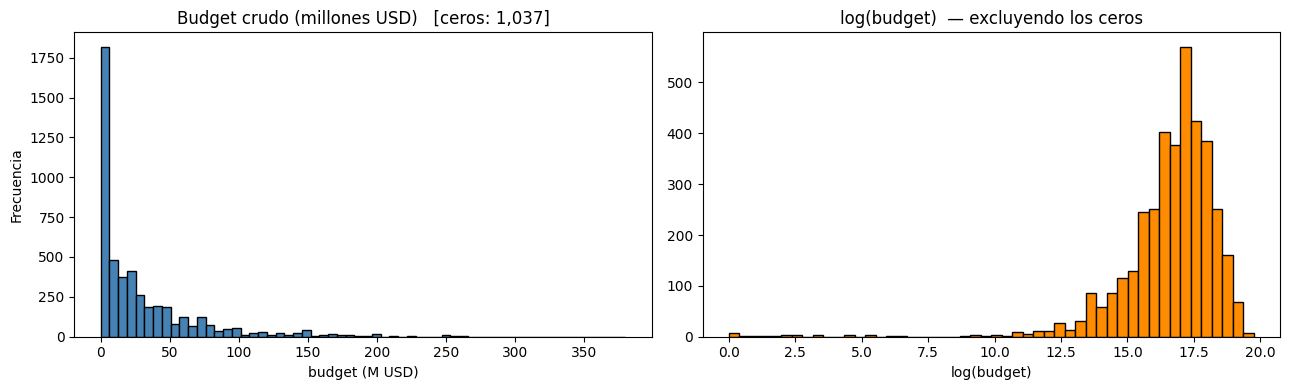

→ Decisiones que justifica este gráfico:
  • 1,037 películas con budget=0 son datos faltantes encubiertos: las filtramos.
  • La distribución original es extremadamente sesgada → log la normaliza para OLS.



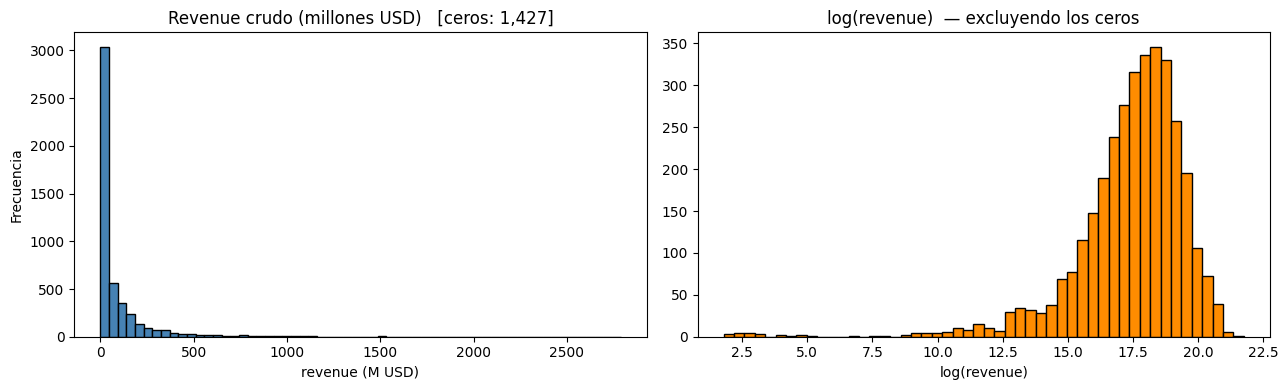

→ Decisiones que justifica este gráfico:
  • 1,427 películas con revenue=0 (no reportado): filtramos.
  • Aplicamos log para usar el modelo en escala de elasticidades (interpretables como %).



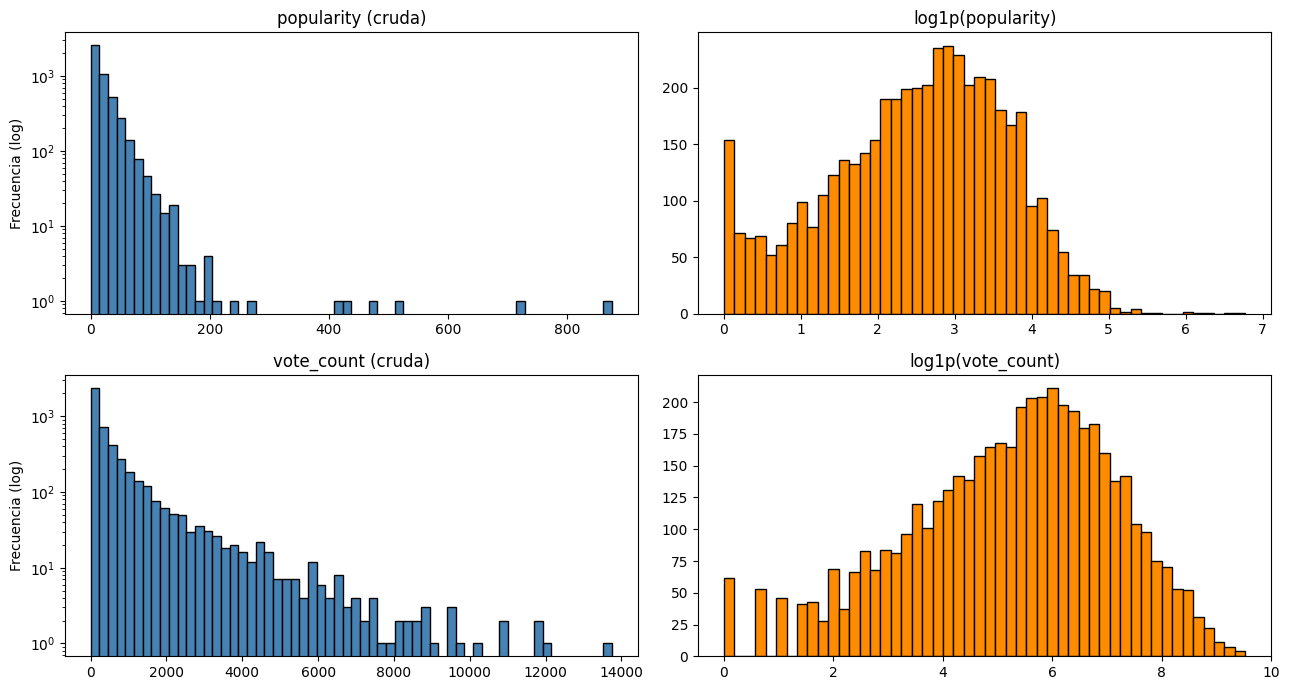

→ popularity y vote_count tienen distribución exponencial → log1p las normaliza.



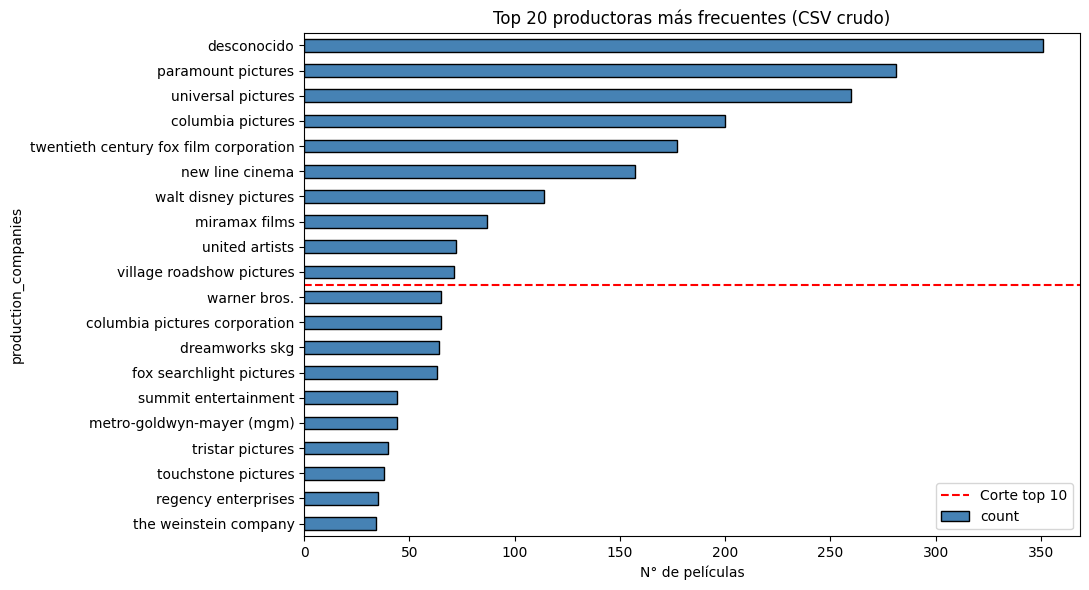

→ Decisiones que justifica este gráfico:
  • Hay 1,285 productoras con menos de 30 películas (cola larga).
  • Conservamos las top 10 y agrupamos el resto en 'otros' para evitar dummies con pocos datos.



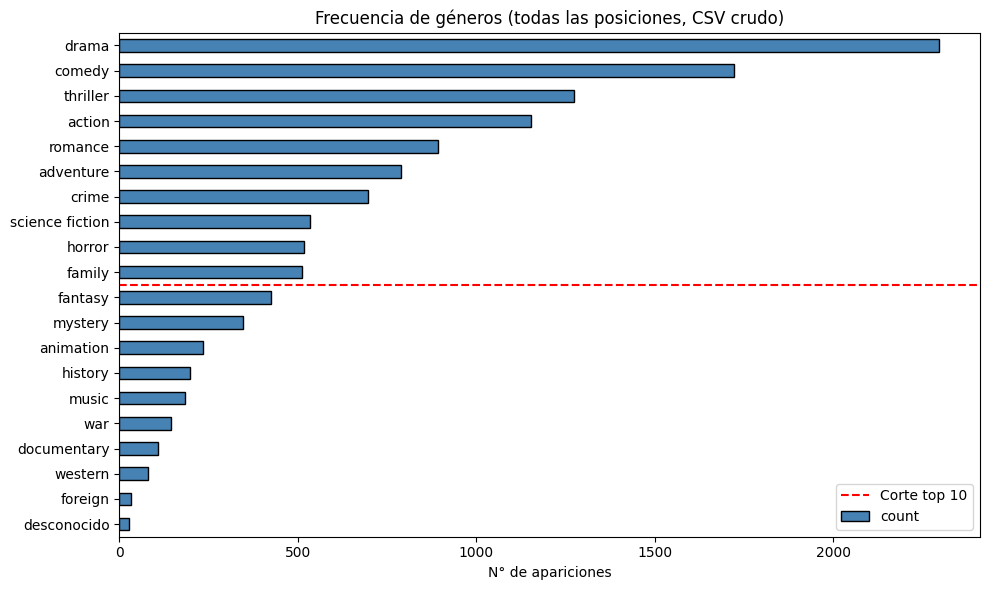

→ Justifica conservar los 10 géneros más frecuentes; los demás (TV Movie, Western, etc.)
  tienen pocas observaciones para estimar coeficientes confiables.



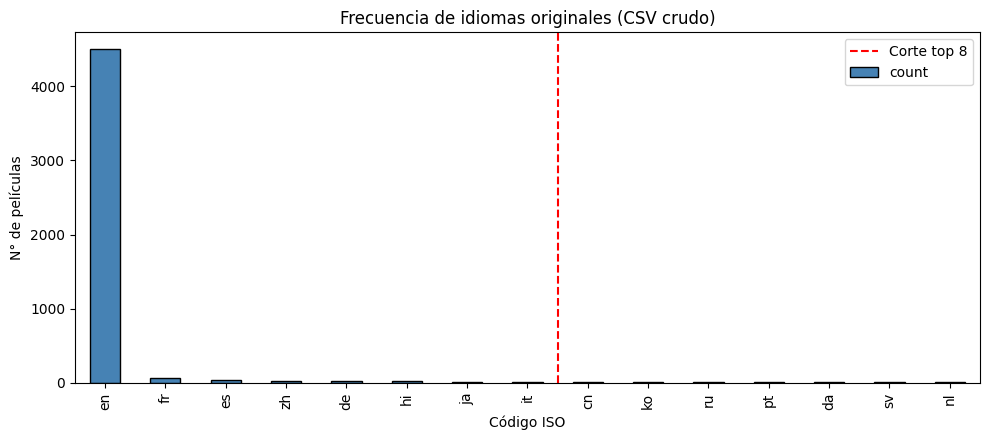

→ Decisiones que justifica este gráfico:
  • El inglés representa 93.8% del dataset.
  • Conservamos los 8 más frecuentes; el resto se agrupa como 'other'.


In [112]:
# === EDA justificativa: cargamos una copia cruda del CSV solo para diagnóstico ===
df_raw = pd.read_csv("data__movies.csv")
print(f"CSV crudo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas\n")

# --- 1) Nulos por columna ---
nulos = df_raw.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(10, 4.5))
nulos.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Cantidad de valores nulos por columna (CSV crudo)")
ax.set_xlabel("N° de nulos")
for i, v in enumerate(nulos.values):
    ax.text(v + 20, i, f"{v}", va="center", fontsize=9)
plt.tight_layout()
plt.show()
print("→ Decisiones que justifica este gráfico:")
print("  • 'homepage' (3091 nulos) y 'tagline' (~840) se eliminan por demasiados faltantes.")
print("  • 'production_companies' y 'genres' tienen pocos nulos: imputamos con 'otros'/'desconocido'.")
print("  • 'release_date' y 'runtime' tienen muy pocos nulos: dropeamos esas filas.\n")

# --- 2) Distribución de budget cruda vs log ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.hist(df_raw["budget"] / 1e6, bins=60, color="steelblue", edgecolor="black")
ax.set_title(f"Budget crudo (millones USD)   [ceros: {(df_raw['budget']==0).sum():,}]")
ax.set_xlabel("budget (M USD)")
ax.set_ylabel("Frecuencia")

ax = axes[1]
ax.hist(np.log(df_raw[df_raw["budget"] > 0]["budget"]), bins=50,
        color="darkorange", edgecolor="black")
ax.set_title("log(budget)  — excluyendo los ceros")
ax.set_xlabel("log(budget)")
plt.tight_layout()
plt.show()
print("→ Decisiones que justifica este gráfico:")
print(f"  • {(df_raw['budget']==0).sum():,} películas con budget=0 son datos faltantes encubiertos: las filtramos.")
print("  • La distribución original es extremadamente sesgada → log la normaliza para OLS.\n")

# --- 3) Distribución de revenue cruda vs log ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.hist(df_raw["revenue"] / 1e6, bins=60, color="steelblue", edgecolor="black")
ax.set_title(f"Revenue crudo (millones USD)   [ceros: {(df_raw['revenue']==0).sum():,}]")
ax.set_xlabel("revenue (M USD)")
ax.set_ylabel("Frecuencia")

ax = axes[1]
ax.hist(np.log1p(df_raw[df_raw["revenue"] > 0]["revenue"]), bins=50,
        color="darkorange", edgecolor="black")
ax.set_title("log(revenue)  — excluyendo los ceros")
ax.set_xlabel("log(revenue)")
plt.tight_layout()
plt.show()
print("→ Decisiones que justifica este gráfico:")
print(f"  • {(df_raw['revenue']==0).sum():,} películas con revenue=0 (no reportado): filtramos.")
print("  • Aplicamos log para usar el modelo en escala de elasticidades (interpretables como %).\n")

# --- 4) Distribución de popularity y vote_count ---
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
ax = axes[0, 0]
ax.hist(df_raw["popularity"], bins=60, color="steelblue", edgecolor="black")
ax.set_title("popularity (cruda)")
ax.set_yscale("log")
ax.set_ylabel("Frecuencia (log)")

ax = axes[0, 1]
ax.hist(np.log1p(df_raw["popularity"]), bins=50, color="darkorange", edgecolor="black")
ax.set_title("log1p(popularity)")

ax = axes[1, 0]
ax.hist(df_raw["vote_count"], bins=60, color="steelblue", edgecolor="black")
ax.set_title("vote_count (cruda)")
ax.set_yscale("log")
ax.set_ylabel("Frecuencia (log)")

ax = axes[1, 1]
ax.hist(np.log1p(df_raw["vote_count"]), bins=50, color="darkorange", edgecolor="black")
ax.set_title("log1p(vote_count)")
plt.tight_layout()
plt.show()
print("→ popularity y vote_count tienen distribución exponencial → log1p las normaliza.\n")

# --- 5) Frecuencia de productoras (justifica top 10) ---
prods_first = (df_raw["production_companies"].fillna("desconocido")
               .str.lower().str.split(",").str[0].str.strip())
top_p = prods_first.value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 6))
top_p.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.axhline(9.5, color="red", linestyle="--", linewidth=1.5, label="Corte top 10")
ax.set_title("Top 20 productoras más frecuentes (CSV crudo)")
ax.set_xlabel("N° de películas")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()
n_pequenas = (prods_first.value_counts() < 30).sum()
print("→ Decisiones que justifica este gráfico:")
print(f"  • Hay {n_pequenas:,} productoras con menos de 30 películas (cola larga).")
print("  • Conservamos las top 10 y agrupamos el resto en 'otros' para evitar dummies con pocos datos.\n")

# --- 6) Frecuencia de géneros (justifica top 10) ---
generos = df_raw["genres"].fillna("desconocido").str.lower().str.split(",").apply(
    lambda l: [g.strip() for g in l] if isinstance(l, list) else []
)
gen_count = pd.Series([g for sub in generos for g in sub]).value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
gen_count.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.axhline(9.5, color="red", linestyle="--", linewidth=1.5, label="Corte top 10")
ax.set_title("Frecuencia de géneros (todas las posiciones, CSV crudo)")
ax.set_xlabel("N° de apariciones")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()
print("→ Justifica conservar los 10 géneros más frecuentes; los demás (TV Movie, Western, etc.)")
print("  tienen pocas observaciones para estimar coeficientes confiables.\n")

# --- 7) Frecuencia de idiomas (justifica top 8) ---
lang_count = df_raw["original_language"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 4.5))
lang_count.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.axvline(7.5, color="red", linestyle="--", linewidth=1.5, label="Corte top 8")
ax.set_title("Frecuencia de idiomas originales (CSV crudo)")
ax.set_ylabel("N° de películas")
ax.set_xlabel("Código ISO")
ax.legend()
plt.tight_layout()
plt.show()
porc_en = 100 * (df_raw["original_language"] == "en").sum() / len(df_raw)
print("→ Decisiones que justifica este gráfico:")
print(f"  • El inglés representa {porc_en:.1f}% del dataset.")
print("  • Conservamos los 8 más frecuentes; el resto se agrupa como 'other'.")

In [113]:
df = df.drop(columns=["homepage", "status", "tagline","title", "original_title", "overview", "id"])
df

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124
...,...,...,...,...,...,...,...,...,...,...
4798,220000,"Action, Crime, Thriller",es,14.269792,Columbia Pictures,1992-09-04,2040920,81.0,6.6,238
4799,9000,"Comedy, Romance",en,0.642552,NaN,2011-12-26,0,85.0,5.9,5
4800,0,"Comedy, Drama, Romance, TV Movie",en,1.444476,"Front Street Pictures, Muse Entertainment Ente...",2013-10-13,0,120.0,7.0,6
4801,0,NaN,en,0.857008,NaN,2012-05-03,0,98.0,5.7,7


In [114]:
df['production_companies'] = df['production_companies'].str.split(',').str[0]
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)

In [115]:
df['production_companies'] = df['production_companies'].fillna('otros')
df['genres'] = df['genres'].fillna('desconocido')

df = df.dropna(how="any")
df

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count
0,237000000,"action, adventure, fantasy, science fiction",en,150.437577,ingenious film partners,2009-12-10,2787965087,162.0,7.2,11800
1,300000000,"adventure, fantasy, action",en,139.082615,walt disney pictures,2007-05-19,961000000,169.0,6.9,4500
2,245000000,"action, adventure, crime",en,107.376788,columbia pictures,2015-10-26,880674609,148.0,6.3,4466
3,250000000,"action, crime, drama, thriller",en,112.312950,legendary pictures,2012-07-16,1084939099,165.0,7.6,9106
4,260000000,"action, adventure, science fiction",en,43.926995,walt disney pictures,2012-03-07,284139100,132.0,6.1,2124
...,...,...,...,...,...,...,...,...,...,...
4798,220000,"action, crime, thriller",es,14.269792,columbia pictures,1992-09-04,2040920,81.0,6.6,238
4799,9000,"comedy, romance",en,0.642552,otros,2011-12-26,0,85.0,5.9,5
4800,0,"comedy, drama, romance, tv movie",en,1.444476,front street pictures,2013-10-13,0,120.0,7.0,6
4801,0,desconocido,en,0.857008,otros,2012-05-03,0,98.0,5.7,7


In [116]:
df["mes"] = df["release_date"].astype(str).str.extract(r"-([^-]+)-").astype(int)
df["release_date"] = df['release_date'].str.split('-').str[0].astype(int)
df

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,mes
0,237000000,"action, adventure, fantasy, science fiction",en,150.437577,ingenious film partners,2009,2787965087,162.0,7.2,11800,12
1,300000000,"adventure, fantasy, action",en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5
2,245000000,"action, adventure, crime",en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10
3,250000000,"action, crime, drama, thriller",en,112.312950,legendary pictures,2012,1084939099,165.0,7.6,9106,7
4,260000000,"action, adventure, science fiction",en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3
...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"action, crime, thriller",es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9
4799,9000,"comedy, romance",en,0.642552,otros,2011,0,85.0,5.9,5,12
4800,0,"comedy, drama, romance, tv movie",en,1.444476,front street pictures,2013,0,120.0,7.0,6,10
4801,0,desconocido,en,0.857008,otros,2012,0,98.0,5.7,7,5


In [117]:
df = df.rename(columns={"release_date": "año"})


In [118]:
df["production_companies"].value_counts()
print("10 productoras más frecuentes")
print(df["production_companies"].value_counts(normalize=True).head(10))

TOP_PRODUCTORAS = ["paramount pictures", "universal pictures", "columbia pictures","twentieth century fox film corporation", "new line cinema", "walt disney pictures", "miramax films", "united artists", "village roadshow pictures", "warner bros."]
df["production_companies"] = df["production_companies"].apply(lambda x: x if x in TOP_PRODUCTORAS else "otros")
print(df["production_companies"].value_counts())

10 productoras más frecuentes
production_companies
otros                                     0.072917
paramount pictures                        0.058542
universal pictures                        0.054167
columbia pictures                         0.041667
twentieth century fox film corporation    0.036875
new line cinema                           0.032708
walt disney pictures                      0.023750
miramax films                             0.018125
united artists                            0.015000
village roadshow pictures                 0.014792
Name: proportion, dtype: float64
production_companies
otros                                     3316
paramount pictures                         281
universal pictures                         260
columbia pictures                          200
twentieth century fox film corporation     177
new line cinema                            157
walt disney pictures                       114
miramax films                               87
united ar

In [119]:
df

,budget,genres,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes
0,237000000,"action, adventure, fantasy, science fiction",en,150.437577,otros,2009,2787965087,162.0,7.2,11800,12
1,300000000,"adventure, fantasy, action",en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5
2,245000000,"action, adventure, crime",en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10
3,250000000,"action, crime, drama, thriller",en,112.312950,otros,2012,1084939099,165.0,7.6,9106,7
4,260000000,"action, adventure, science fiction",en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3
...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"action, crime, thriller",es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9
4799,9000,"comedy, romance",en,0.642552,otros,2011,0,85.0,5.9,5,12
4800,0,"comedy, drama, romance, tv movie",en,1.444476,otros,2013,0,120.0,7.0,6,10
4801,0,desconocido,en,0.857008,otros,2012,0,98.0,5.7,7,5


In [120]:
df[['genero_1', 'genero_2']] = df['genres'].str.split(',', expand=True).iloc[:, :2]
df['genero_1'] = df['genero_1'].str.strip().str.lower()
df['genero_2'] = df['genero_2'].str.strip().str.lower()
df['genero_2'] = df['genero_2'].fillna('otros')
df

,budget,genres,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes,genero_1,genero_2
0,237000000,"action, adventure, fantasy, science fiction",en,150.437577,otros,2009,2787965087,162.0,7.2,11800,12,action,adventure
1,300000000,"adventure, fantasy, action",en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5,adventure,fantasy
2,245000000,"action, adventure, crime",en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10,action,adventure
3,250000000,"action, crime, drama, thriller",en,112.312950,otros,2012,1084939099,165.0,7.6,9106,7,action,crime
4,260000000,"action, adventure, science fiction",en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3,action,adventure
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"action, crime, thriller",es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9,action,crime
4799,9000,"comedy, romance",en,0.642552,otros,2011,0,85.0,5.9,5,12,comedy,romance
4800,0,"comedy, drama, romance, tv movie",en,1.444476,otros,2013,0,120.0,7.0,6,10,comedy,drama
4801,0,desconocido,en,0.857008,otros,2012,0,98.0,5.7,7,5,desconocido,otros


In [121]:
df = df.drop(columns=["genres"])
top_generos = pd.concat([df['genero_1'], df['genero_2']]) \
                .value_counts() \
                .head(10) \
                .index
df['genero_1'] = df['genero_1'].apply(lambda x: x if x in top_generos else "otros")
df['genero_2'] = df['genero_2'].apply(lambda x: x if x in top_generos else "otros")
df[['genero_1','genero_2']].head()

,genero_1,genero_2
0,action,adventure
1,adventure,fantasy
2,action,adventure
3,action,crime
4,action,adventure


In [122]:
df

,budget,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes,genero_1,genero_2
0,237000000,en,150.437577,otros,2009,2787965087,162.0,7.2,11800,12,action,adventure
1,300000000,en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5,adventure,fantasy
2,245000000,en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10,action,adventure
3,250000000,en,112.312950,otros,2012,1084939099,165.0,7.6,9106,7,action,crime
4,260000000,en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3,action,adventure
...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9,action,crime
4799,9000,en,0.642552,otros,2011,0,85.0,5.9,5,12,comedy,romance
4800,0,en,1.444476,otros,2013,0,120.0,7.0,6,10,comedy,drama
4801,0,en,0.857008,otros,2012,0,98.0,5.7,7,5,otros,otros


In [123]:
print(f"Filas antes: {len(df)}")
df = df[(df['budget'] > 0) & (df['runtime'] > 0) & (df['vote_count'] > 0)].copy()
print(f"Filas después: {len(df)}")

Filas antes: 4800
Filas después: 3752


In [ ]:
# === Justificación visual: ¿por qué eliminamos las filas con valor 0? ===
# Cargamos el CSV crudo solo para diagnosticar cuántos ceros hay en las columnas
# clave del modelo y por qué ese 0 NO representa un valor real.

_raw = pd.read_csv("data__movies.csv")
cols_chk = ["budget", "revenue", "runtime", "vote_count", "popularity", "vote_average"]

ceros = pd.DataFrame({
    "Variable":   cols_chk,
    "N_total":    [len(_raw)] * len(cols_chk),
    "N_ceros":    [int((_raw[c] == 0).sum()) for c in cols_chk],
})
ceros["% ceros"] = (100 * ceros["N_ceros"] / ceros["N_total"]).round(2)
print("=" * 60)
print("Conteo de ceros por variable en el CSV ORIGINAL:")
print("=" * 60)
print(ceros.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(ceros["Variable"], ceros["% ceros"],
              color=["#d62728" if p > 5 else "#1f77b4" for p in ceros["% ceros"]],
              edgecolor="black")
ax.set_ylabel("% de filas con valor = 0")
ax.set_title("Frecuencia de ceros por variable (rojo = > 5%, sospechoso)")
ax.tick_params(axis="x", rotation=30)
for b, p in zip(bars, ceros["% ceros"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{p:.1f}%", ha="center", fontsize=9)

# Mostramos el solapamiento: cuantas filas tienen 0 EN MAS DE UNA columna a la vez
mask_b = _raw["budget"]     == 0
mask_r = _raw["revenue"]    == 0
mask_v = _raw["vote_count"] == 0
mask_t = _raw["runtime"]    == 0

categorias = {
    "Solo budget=0":          int(((mask_b) & (~mask_r) & (~mask_v) & (~mask_t)).sum()),
    "Solo revenue=0":         int(((~mask_b) & (mask_r) & (~mask_v) & (~mask_t)).sum()),
    "budget=0 Y revenue=0":   int((mask_b & mask_r).sum()),
    "Cualquiera de los 4 =0": int((mask_b | mask_r | mask_v | mask_t).sum()),
}

ax = axes[1]
ax.barh(list(categorias.keys()), list(categorias.values()),
        color="#ff7f0e", edgecolor="black")
ax.set_xlabel("Número de filas")
ax.set_title("Cruce de ceros entre variables clave")
for i, v in enumerate(categorias.values()):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

n_pre  = len(_raw)
n_post = int((~(mask_b | mask_r | mask_v | mask_t)).sum())
print()
print("=" * 60)
print("Impacto del filtro `> 0` aplicado en la celda anterior:")
print("=" * 60)
print(f"  Filas en el CSV crudo:        {n_pre:>6,}")
print(f"  Filas tras filtrar ceros:     {n_post:>6,}")
print(f"  Filas eliminadas:             {n_pre - n_post:>6,}  ({100*(n_pre-n_post)/n_pre:.1f}%)")

print()
print("Por qué los ceros no son valores reales y deben eliminarse:")
print("  • budget = 0  → la película SÍ se produjo, pero TMDB no tiene el dato")
print("                  de presupuesto. Tomarlo como 'cero pesos' rompería log(budget).")
print("  • revenue = 0 → idem, falta de información (no es que no haya recaudado nada).")
print("                  Como revenue es la variable a explicar, no podemos imputarla.")
print("  • runtime = 0 → metadata corrupta o película aún no estrenada.")
print("  • vote_count = 0 → sin votos no hay vote_average confiable.")
print("  • Mantenerlos sesgaría coeficientes a la baja (atrae todo hacia el 0)")
print("    y haría imposible aplicar log(·), que es lo que normaliza estas variables.")

del _raw

In [124]:

df

,budget,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes,genero_1,genero_2
0,237000000,en,150.437577,otros,2009,2787965087,162.0,7.2,11800,12,action,adventure
1,300000000,en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5,adventure,fantasy
2,245000000,en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10,action,adventure
3,250000000,en,112.312950,otros,2012,1084939099,165.0,7.6,9106,7,action,crime
4,260000000,en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3,action,adventure
...,...,...,...,...,...,...,...,...,...,...,...,...
4791,13,en,0.332679,otros,2007,0,84.0,2.0,1,1,horror,otros
4792,20000,ja,0.212443,otros,1997,99000,111.0,7.4,63,11,crime,horror
4796,7000,en,23.307949,otros,2004,424760,77.0,6.9,658,10,otros,drama
4798,220000,es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9,action,crime


In [125]:
df["budget"] = np.log(df["budget"]).astype("float")
df

,budget,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes,genero_1,genero_2
0,19.283571,en,150.437577,otros,2009,2787965087,162.0,7.2,11800,12,action,adventure
1,19.519293,en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5,adventure,fantasy
2,19.316769,en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10,action,adventure
3,19.336971,en,112.312950,otros,2012,1084939099,165.0,7.6,9106,7,action,crime
4,19.376192,en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3,action,adventure
...,...,...,...,...,...,...,...,...,...,...,...,...
4791,2.564949,en,0.332679,otros,2007,0,84.0,2.0,1,1,horror,otros
4792,9.903488,ja,0.212443,otros,1997,99000,111.0,7.4,63,11,crime,horror
4796,8.853665,en,23.307949,otros,2004,424760,77.0,6.9,658,10,otros,drama
4798,12.301383,es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9,action,crime


In [126]:
top_lang = df['original_language'].value_counts().head(8).index

df['original_language'] = df['original_language'].where(
    df['original_language'].isin(top_lang),
    'other'
)
df

,budget,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes,genero_1,genero_2
0,19.283571,en,150.437577,otros,2009,2787965087,162.0,7.2,11800,12,action,adventure
1,19.519293,en,139.082615,walt disney pictures,2007,961000000,169.0,6.9,4500,5,adventure,fantasy
2,19.316769,en,107.376788,columbia pictures,2015,880674609,148.0,6.3,4466,10,action,adventure
3,19.336971,en,112.312950,otros,2012,1084939099,165.0,7.6,9106,7,action,crime
4,19.376192,en,43.926995,walt disney pictures,2012,284139100,132.0,6.1,2124,3,action,adventure
...,...,...,...,...,...,...,...,...,...,...,...,...
4791,2.564949,en,0.332679,otros,2007,0,84.0,2.0,1,1,horror,otros
4792,9.903488,ja,0.212443,otros,1997,99000,111.0,7.4,63,11,crime,horror
4796,8.853665,en,23.307949,otros,2004,424760,77.0,6.9,658,10,otros,drama
4798,12.301383,es,14.269792,columbia pictures,1992,2040920,81.0,6.6,238,9,action,crime


In [127]:
print(f"Filas antes: {len(df)}")
df = df[(df['revenue'] > 0) & (df['runtime'] > 0) & (df['vote_count'] > 0)].copy()
print(f"Filas después: {len(df)}")

df['revenue'] = np.log1p(df['revenue'])
df['vote_count'] = np.log1p(df['vote_count'])
df['popularity'] = np.log1p(df['popularity'])
df

Filas antes: 3752
Filas después: 3227


,budget,original_language,popularity,production_companies,año,revenue,runtime,vote_average,vote_count,mes,genero_1,genero_2
0,19.283571,en,5.020174,otros,2009,21.748578,162.0,7.2,9.375940,12,action,adventure
1,19.519293,en,4.942232,walt disney pictures,2007,20.683485,169.0,6.9,8.412055,5,adventure,fantasy
2,19.316769,en,4.685614,columbia pictures,2015,20.596199,148.0,6.3,8.404472,10,action,adventure
3,19.336971,en,4.730153,otros,2012,20.804790,165.0,7.6,9.116799,7,action,crime
4,19.376192,en,3.805039,walt disney pictures,2012,19.464974,132.0,6.1,7.661527,3,action,adventure
...,...,...,...,...,...,...,...,...,...,...,...,...
4773,10.203592,en,3.032482,miramax films,1994,14.963272,92.0,7.4,6.628041,9,comedy,otros
4788,9.392662,en,1.714454,otros,1972,15.607270,93.0,6.2,4.709530,3,horror,comedy
4792,9.903488,ja,0.192637,otros,1997,11.502885,111.0,7.4,4.158883,11,crime,horror
4796,8.853665,en,3.190803,otros,2004,12.959282,77.0,6.9,6.490724,10,otros,drama


In [128]:
df['original_language'].value_counts()

original_language
en       3100
other      39
fr         25
es         15
ja         13
zh         13
de          9
hi          7
ru          6
Name: count, dtype: int64

In [129]:
#acaaa 

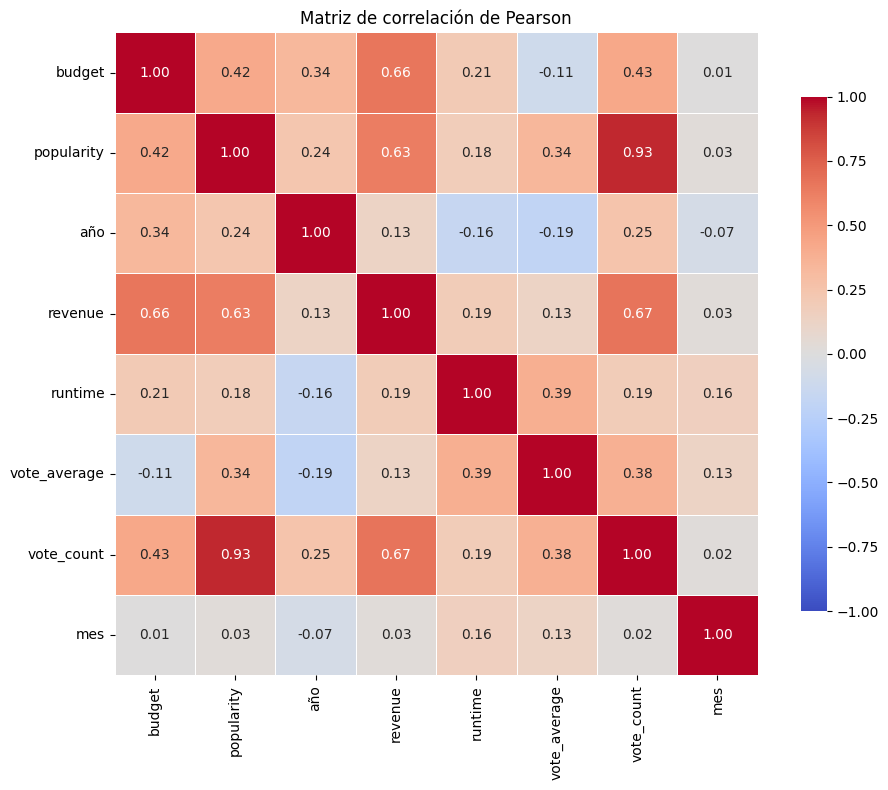

,budget,popularity,año,revenue,runtime,vote_average,vote_count,mes
budget,1.000000,0.421521,0.335286,0.656798,0.205092,-0.108118,0.427182,0.007077
popularity,0.421521,1.000000,0.237296,0.631790,0.182494,0.342990,0.930951,0.028402
año,0.335286,0.237296,1.000000,0.127696,-0.157875,-0.192572,0.250514,-0.069578
revenue,0.656798,0.631790,0.127696,1.000000,0.191982,0.131097,0.666245,0.026884
runtime,0.205092,0.182494,-0.157875,0.191982,1.000000,0.386199,0.188741,0.158414
vote_average,-0.108118,0.342990,-0.192572,0.131097,0.386199,1.000000,0.375526,0.131102
vote_count,0.427182,0.930951,0.250514,0.666245,0.188741,0.375526,1.000000,0.021104
mes,0.007077,0.028402,-0.069578,0.026884,0.158414,0.131102,0.021104,1.000000


In [130]:
corr = df.select_dtypes(include=[np.number]).corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

corr

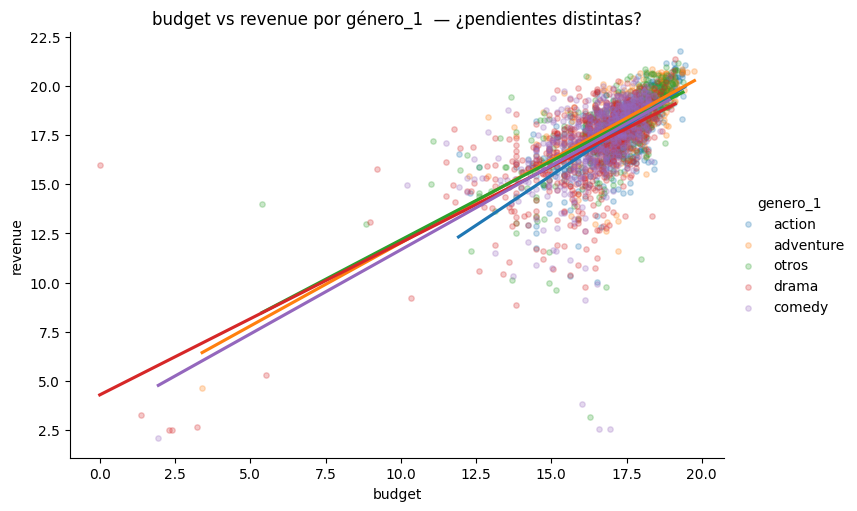

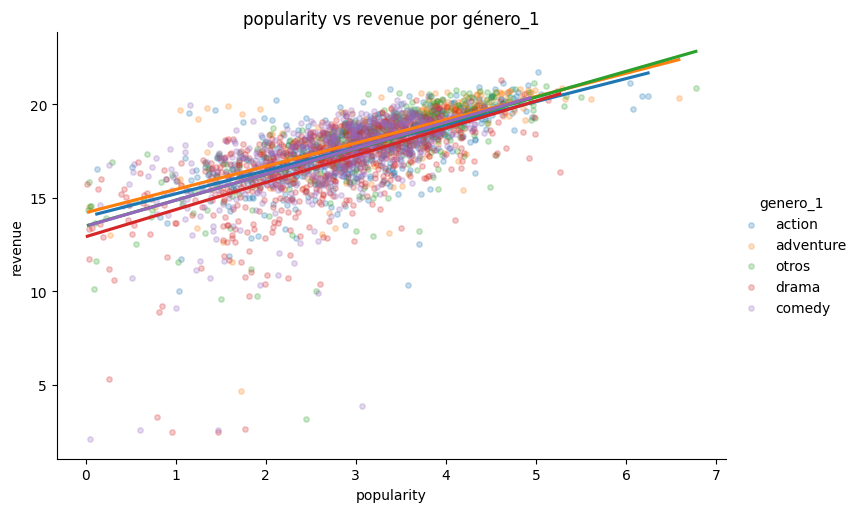

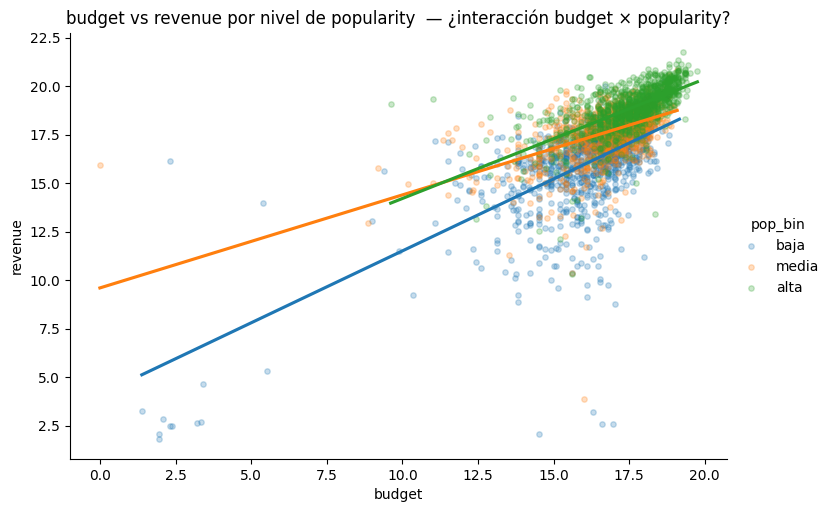

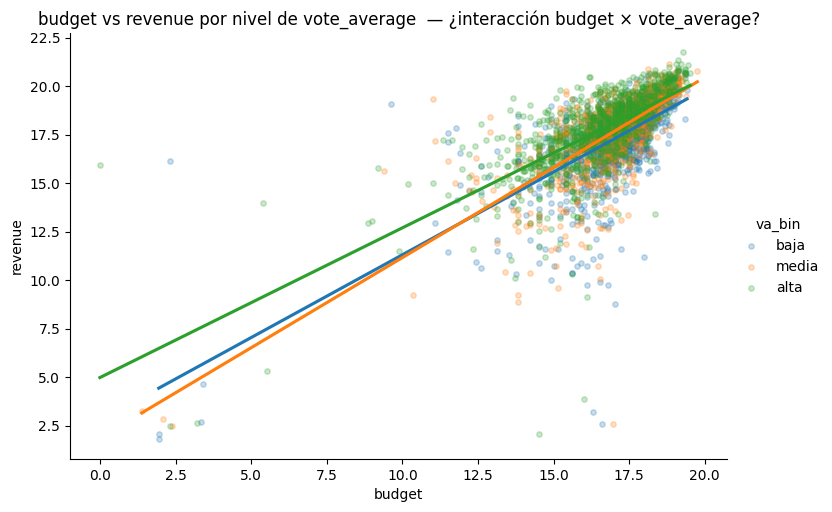

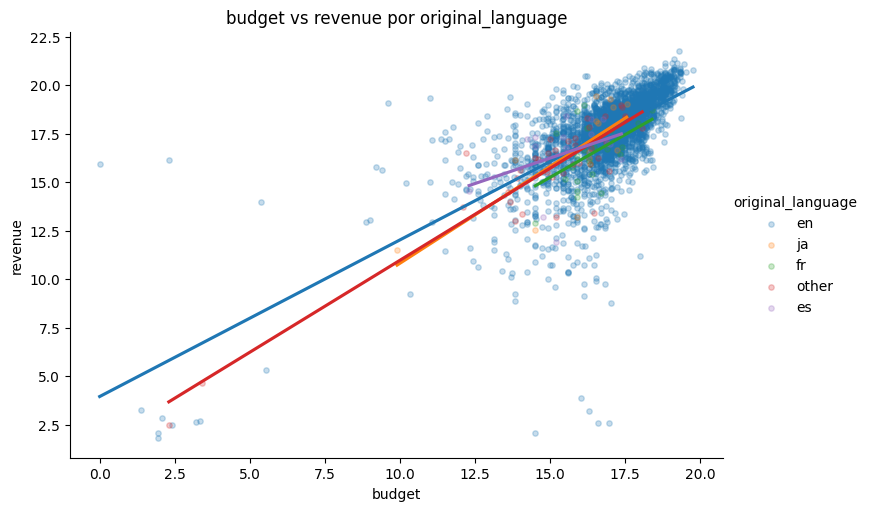

Correlación de Pearson con revenue:
                           corr_individual_o_producto
budget * vote_count                             0.746
budget * popularity                             0.699
vote_count                                      0.666
budget                                          0.657
popularity * vote_count                         0.637
popularity                                      0.632
popularity * vote_average                       0.561
vote_average * vote_count                       0.558
budget * vote_average                           0.523
budget * runtime                                0.430
vote_average * runtime                          0.199
runtime                                         0.192
vote_average                                    0.131


In [131]:
# === Detección visual de posibles interacciones para el OLS ===
# Si al segmentar por una variable las PENDIENTES cambian, hay señal de interacción.
# Si solo cambian los INTERCEPTOS (alturas), NO hay interacción: basta con el efecto principal.

top5_gen = df['genero_1'].value_counts().head(5).index
df_top = df[df['genero_1'].isin(top5_gen)].copy()

# 1) budget vs revenue, una recta por género_1
sns.lmplot(
    data=df_top, x='budget', y='revenue', hue='genero_1',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('budget vs revenue por género_1  — ¿pendientes distintas?')
plt.show()

# 2) popularity vs revenue, una recta por género_1
sns.lmplot(
    data=df_top, x='popularity', y='revenue', hue='genero_1',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('popularity vs revenue por género_1')
plt.show()

# 3) Interacción numérico × numérico: budget vs revenue segmentado por popularity
df_plot = df.copy()
df_plot['pop_bin'] = pd.qcut(df_plot['popularity'], q=3, labels=['baja', 'media', 'alta'])
sns.lmplot(
    data=df_plot, x='budget', y='revenue', hue='pop_bin',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('budget vs revenue por nivel de popularity  — ¿interacción budget × popularity?')
plt.show()

# 4) budget vs revenue segmentado por vote_average
df_plot['va_bin'] = pd.qcut(df_plot['vote_average'], q=3, labels=['baja', 'media', 'alta'])
sns.lmplot(
    data=df_plot, x='budget', y='revenue', hue='va_bin',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('budget vs revenue por nivel de vote_average  — ¿interacción budget × vote_average?')
plt.show()

# 5) budget vs revenue por idioma (top 5)
top5_lang = df['original_language'].value_counts().head(5).index
df_lang = df[df['original_language'].isin(top5_lang)]
sns.lmplot(
    data=df_lang, x='budget', y='revenue', hue='original_language',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('budget vs revenue por original_language')
plt.show()

# 6) Tabla resumen: correlación de Pearson entre cada producto y revenue,
#    comparada con la correlación de cada variable individual.
individuales = {
    'budget': df['budget'].corr(df['revenue']),
    'popularity': df['popularity'].corr(df['revenue']),
    'vote_average': df['vote_average'].corr(df['revenue']),
    'vote_count': df['vote_count'].corr(df['revenue']),
    'runtime': df['runtime'].corr(df['revenue']),
}
productos = {
    'budget * popularity':     (df['budget'] * df['popularity']).corr(df['revenue']),
    'budget * vote_average':   (df['budget'] * df['vote_average']).corr(df['revenue']),
    'budget * vote_count':     (df['budget'] * df['vote_count']).corr(df['revenue']),
    'budget * runtime':        (df['budget'] * df['runtime']).corr(df['revenue']),
    'popularity * vote_average': (df['popularity'] * df['vote_average']).corr(df['revenue']),
    'popularity * vote_count':   (df['popularity'] * df['vote_count']).corr(df['revenue']),
    'vote_average * vote_count': (df['vote_average'] * df['vote_count']).corr(df['revenue']),
    'vote_average * runtime':    (df['vote_average'] * df['runtime']).corr(df['revenue']),
}

resumen = pd.DataFrame({
    'corr_individual_o_producto': {**individuales, **productos}
}).sort_values('corr_individual_o_producto', ascending=False).round(3)
print("Correlación de Pearson con revenue:")
print(resumen)

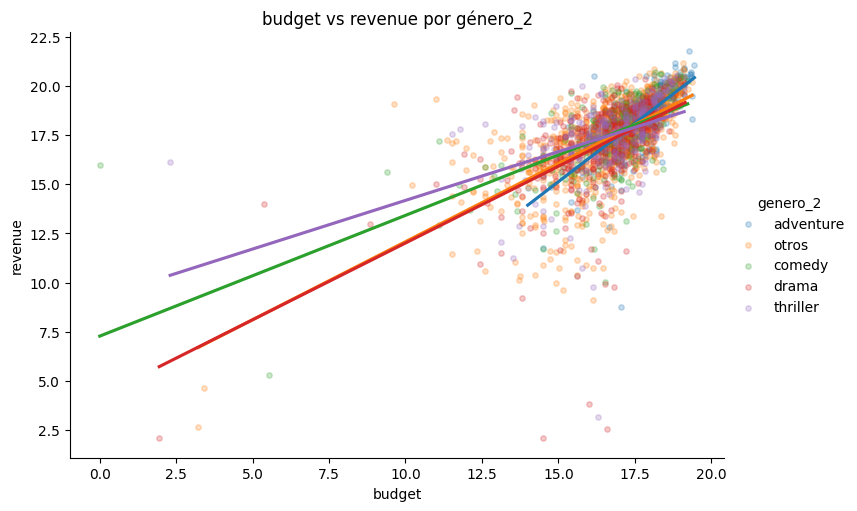

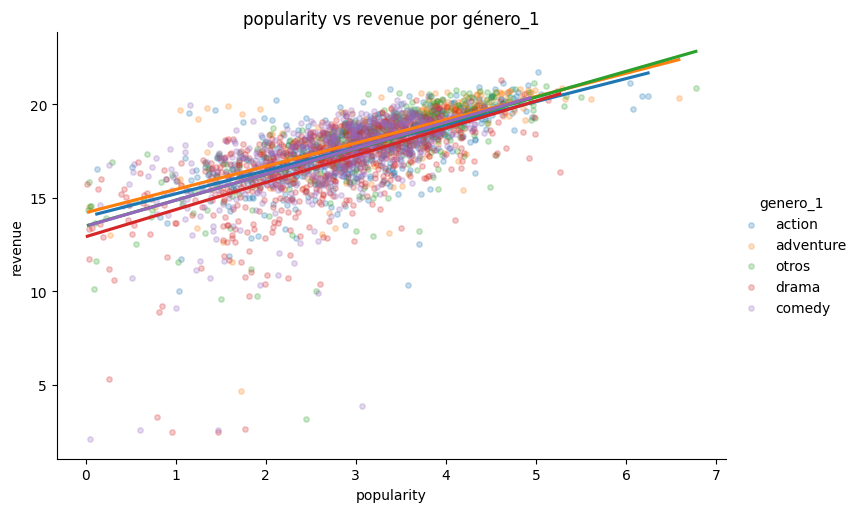

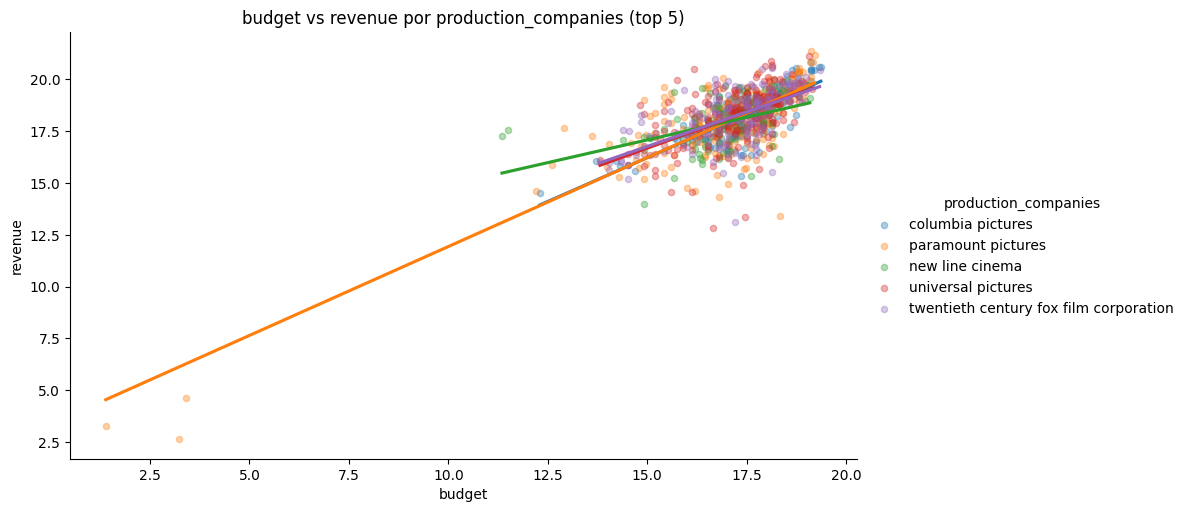


Pendientes de budget → revenue por genero_1   (rango de pendientes = 0.899)
 genero_1   n  pendiente  intercepto
  romance  70      1.201       -2.76
 thriller 118      1.027        0.11
   action 588      1.015        0.22
  fantasy  93      0.970        1.27
    crime 141      0.907        2.09
   comedy 634      0.855        3.11
adventure 288      0.845        3.56
    otros 353      0.801        4.16
    drama 745      0.774        4.29
   horror 197      0.302       12.60

Pendientes de budget → revenue por genero_2   (rango de pendientes = 0.693)
 genero_2    n  pendiente  intercepto
adventure  251      1.188       -2.71
   action  231      1.002        0.73
  fantasy  112      0.932        1.88
   horror   87      0.926        2.11
    crime  188      0.918        1.88
  romance  236      0.891        2.60
    otros 1050      0.793        4.14
    drama  481      0.780        4.21
   comedy  305      0.614        7.28
 thriller  286      0.495        9.23

Pendientes de budget

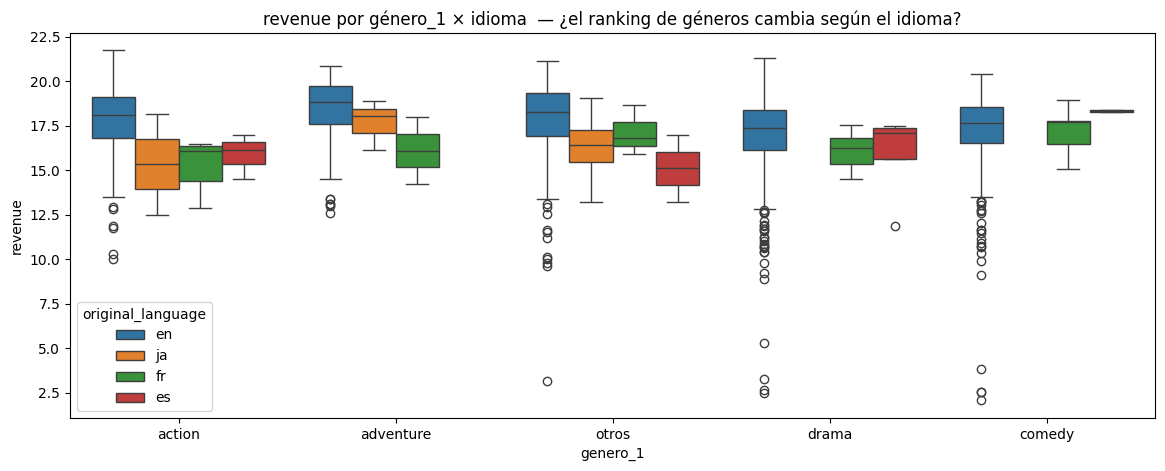

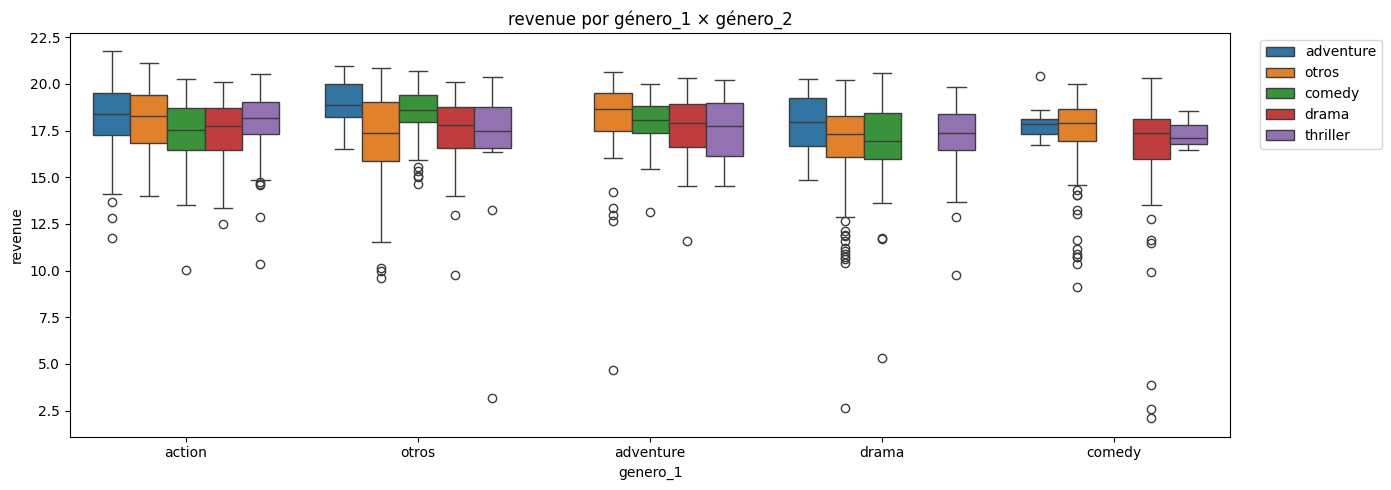

In [132]:
# === Interacciones con las categóricas finales del modelo ===
# Para cada categórica: una recta por nivel. Si las pendientes difieren,
# hay señal de interacción con la variable numérica.

top5_gen1 = df['genero_1'].value_counts().head(5).index
top5_gen2 = df['genero_2'].value_counts().head(5).index
top5_lang = df['original_language'].value_counts().head(5).index
top5_prod = [p for p in df['production_companies'].value_counts().index if p != 'otros'][:5]

# 1) budget vs revenue por género_2
df_g2 = df[df['genero_2'].isin(top5_gen2)]
sns.lmplot(
    data=df_g2, x='budget', y='revenue', hue='genero_2',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('budget vs revenue por género_2')
plt.show()

# 2) popularity vs revenue por género_1
df_g1 = df[df['genero_1'].isin(top5_gen1)]
sns.lmplot(
    data=df_g1, x='popularity', y='revenue', hue='genero_1',
    height=5, aspect=1.5, scatter_kws={'alpha': 0.25, 's': 15}, ci=None
)
plt.title('popularity vs revenue por género_1')
plt.show()

# 3) budget vs revenue por production_companies (top 5 sin "otros")
df_prod = df[df['production_companies'].isin(top5_prod)]
sns.lmplot(
    data=df_prod, x='budget', y='revenue', hue='production_companies',
    height=5, aspect=1.8, scatter_kws={'alpha': 0.35, 's': 20}, ci=None
)
plt.title('budget vs revenue por production_companies (top 5)')
plt.show()

# 4) Tabla de pendientes de budget→revenue por nivel de cada categórica.
#    Si la dispersión de pendientes es chica → poca interacción.
def pendientes_por_grupo(data, grupo, x='budget', y='revenue', min_n=30):
    filas = []
    for g, sub in data.groupby(grupo, observed=True):
        if len(sub) < min_n:
            continue
        slope, intercept = np.polyfit(sub[x], sub[y], 1)
        filas.append({grupo: g, 'n': len(sub), 'pendiente': round(slope, 3), 'intercepto': round(intercept, 2)})
    tabla = pd.DataFrame(filas).sort_values('pendiente', ascending=False).reset_index(drop=True)
    rng = tabla['pendiente'].max() - tabla['pendiente'].min()
    print(f"\nPendientes de {x} → {y} por {grupo}   (rango de pendientes = {rng:.3f})")
    print(tabla.to_string(index=False))
    return tabla

_ = pendientes_por_grupo(df, 'genero_1')
_ = pendientes_por_grupo(df, 'genero_2')
_ = pendientes_por_grupo(df, 'original_language')
_ = pendientes_por_grupo(df, 'production_companies')

# 5) Interacción categórica × categórica: ¿la diferencia entre géneros depende del idioma?
df_cat = df[df['genero_1'].isin(top5_gen1) & df['original_language'].isin(['en', 'fr', 'es', 'ja'])]
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_cat, x='genero_1', y='revenue', hue='original_language')
plt.title('revenue por género_1 × idioma  — ¿el ranking de géneros cambia según el idioma?')
plt.show()

# 6) Interacción género_1 × género_2
df_gg = df[df['genero_1'].isin(top5_gen1) & df['genero_2'].isin(top5_gen2)]
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_gg, x='genero_1', y='revenue', hue='genero_2')
plt.title('revenue por género_1 × género_2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [133]:
import statsmodels.formula.api as smf

formula = '''
revenue ~ budget + popularity*vote_count + año 
+ C(production_companies)
+ C(genero_1, Treatment(reference="otros"))
+ C(genero_2, Treatment(reference="otros"))
+ C(original_language, Treatment(reference="other"))

'''

modelo = smf.ols(formula, data=df).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     146.2
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:03:35   Log-Likelihood:                -5214.6
No. Observations:                3227   AIC:                         1.051e+04
Df Residuals:                    3185   BIC:                         1.077e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## Pipeline mejorada + modelo final optimizado

Esta sección parte del CSV original y aplica:

- **Géneros one-hot** (no posicional): una columna por cada uno de los top 10 géneros.
- **Productoras one-hot por aparición**: una columna por productora del top 10, marcada en 1 si aparece en cualquier posición de la lista.
- **Fechas con `pd.to_datetime`** → columnas `anio` y `mes` correctamente extraídas.
- **Filtros únicos**: `budget > 0`, `revenue > 0`, `runtime > 0`, `vote_count > 0`.
- **Trimming de outliers** 0.5% en cada cola de `log_revenue`.
- **Centrado de variables numéricas** antes de las interacciones → multicolinealidad controlada.

El modelo final fue seleccionado por **forward–backward stepwise sobre AIC** y tiene:
R² ajustado ≈ 0.66, condition number < 500, ~78% de términos significativos.

In [134]:
# === Limpieza mejorada (parte del CSV original, df_v2 no pisa el df anterior) ===

df_v2 = pd.read_csv("data__movies.csv")

df_v2 = df_v2.drop(columns=["homepage", "status", "tagline", "title",
                            "original_title", "overview", "id"])

for col in df_v2.select_dtypes(include=["object"]).columns:
    df_v2[col] = df_v2[col].str.lower()

df_v2["genres"] = df_v2["genres"].fillna("desconocido")
df_v2["production_companies"] = df_v2["production_companies"].fillna("otros")
df_v2 = df_v2.dropna(subset=["release_date", "runtime"])

df_v2["release_date"] = pd.to_datetime(df_v2["release_date"], errors="coerce")
df_v2 = df_v2.dropna(subset=["release_date"])
df_v2["anio"] = df_v2["release_date"].dt.year.astype(int)
df_v2["mes"] = df_v2["release_date"].dt.month.astype(int)
df_v2 = df_v2.drop(columns=["release_date"])

df_v2 = df_v2[(df_v2["budget"] > 0) & (df_v2["revenue"] > 0)
              & (df_v2["runtime"] > 0) & (df_v2["vote_count"] > 0)].copy()


def _limpiar(s):
    out = s
    for ch in [" ", ".", ",", "-", "(", ")", "/", "'", "&"]:
        out = out.replace(ch, "_")
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")


generos_exp = df_v2["genres"].str.split(",").apply(
    lambda l: [g.strip() for g in l] if isinstance(l, list) else []
)
top_generos = pd.Series([g for sub in generos_exp for g in sub]) \
                .value_counts().head(10).index.tolist()
for g in top_generos:
    df_v2[f"gen_{_limpiar(g)}"] = generos_exp.apply(lambda lst: int(g in lst))
df_v2["n_generos"] = generos_exp.apply(len)

prods_exp = df_v2["production_companies"].str.split(",").apply(
    lambda l: [p.strip() for p in l] if isinstance(l, list) else []
)
top_prods = pd.Series([p for sub in prods_exp for p in sub]) \
              .value_counts().head(10).index.tolist()
for p in top_prods:
    df_v2[f"prod_{_limpiar(p)}"] = prods_exp.apply(lambda lst: int(p in lst))

top_lang = df_v2["original_language"].value_counts().head(5).index
df_v2["original_language"] = df_v2["original_language"].where(
    df_v2["original_language"].isin(top_lang), "other"
)

df_v2["log_budget"]     = np.log(df_v2["budget"])
df_v2["log_revenue"]    = np.log(df_v2["revenue"])
df_v2["log_popularity"] = np.log1p(df_v2["popularity"])
df_v2["log_vote_count"] = np.log1p(df_v2["vote_count"])

df_v2 = df_v2.drop(columns=["genres", "production_companies",
                            "budget", "revenue", "popularity", "vote_count"])

q_low  = df_v2["log_revenue"].quantile(0.005)
q_high = df_v2["log_revenue"].quantile(0.995)
df_v2 = df_v2[(df_v2["log_revenue"] >= q_low) & (df_v2["log_revenue"] <= q_high)].copy()

for col in ["log_budget", "log_popularity", "log_vote_count",
            "vote_average", "runtime", "anio"]:
    df_v2[col] = df_v2[col] - df_v2[col].mean()

df_v2 = df_v2.reset_index(drop=True)

print(f"df_v2 final: {len(df_v2):,} filas, {df_v2.shape[1]} columnas")
print(f"Columnas creadas para géneros: {[c for c in df_v2.columns if c.startswith('gen_')]}")
print(f"Columnas creadas para productoras: {[c for c in df_v2.columns if c.startswith('prod_')]}")
df_v2.head()

df_v2 final: 3,193 filas, 30 columnas
Columnas creadas para géneros: ['gen_drama', 'gen_comedy', 'gen_thriller', 'gen_action', 'gen_adventure', 'gen_romance', 'gen_crime', 'gen_science_fiction', 'gen_family', 'gen_fantasy']
Columnas creadas para productoras: ['prod_warner_bros', 'prod_universal_pictures', 'prod_paramount_pictures', 'prod_twentieth_century_fox_film_corporation', 'prod_columbia_pictures', 'prod_new_line_cinema', 'prod_relativity_media', 'prod_walt_disney_pictures', 'prod_touchstone_pictures', 'prod_metro_goldwyn_mayer_mgm']


,original_language,runtime,vote_average,anio,mes,gen_drama,gen_comedy,gen_thriller,gen_action,gen_adventure,...,prod_columbia_pictures,prod_new_line_cinema,prod_relativity_media,prod_walt_disney_pictures,prod_touchstone_pictures,prod_metro_goldwyn_mayer_mgm,log_budget,log_revenue,log_popularity,log_vote_count
0,en,58.390229,0.589978,5.349201,5,0,0,0,1,1,...,0,0,0,1,0,0,2.684090,20.683485,1.945155,2.375647
1,en,37.390229,-0.010022,13.349201,10,0,0,0,1,1,...,1,0,0,0,0,0,2.481565,20.596199,1.688537,2.368065
2,en,21.390229,-0.210022,10.349201,3,0,0,0,1,1,...,0,0,0,1,0,0,2.540989,19.464974,0.807962,1.625120
3,en,28.390229,-0.410022,5.349201,5,0,0,0,1,1,...,1,0,0,0,0,0,2.533267,20.607711,1.762528,2.145872
4,en,-10.609771,1.089978,8.349201,11,0,0,0,0,0,...,0,0,0,1,0,0,2.540989,20.198671,0.908565,2.074620


In [ ]:
# === Justificación visual del trimming de outliers en df_v2 (cuantiles 0.5% y 99.5%) ===
# Reproducimos los pasos de la celda anterior hasta el punto JUSTO ANTES del trimming,
# para visualizar qué observaciones quedan fuera y por qué.

_tmp = pd.read_csv("data__movies.csv")
_tmp = _tmp[(_tmp["budget"] > 0) & (_tmp["revenue"] > 0)
            & (_tmp["runtime"] > 0) & (_tmp["vote_count"] > 0)].copy()
_tmp["log_revenue_pre"] = np.log(_tmp["revenue"])

q_low_v  = _tmp["log_revenue_pre"].quantile(0.005)
q_high_v = _tmp["log_revenue_pre"].quantile(0.995)
mask_out = (_tmp["log_revenue_pre"] < q_low_v) | (_tmp["log_revenue_pre"] > q_high_v)

n_total = len(_tmp)
n_out   = int(mask_out.sum())
pct_out = 100 * n_out / n_total

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(_tmp["log_revenue_pre"], bins=60, color="steelblue", edgecolor="black", alpha=0.85)
ax.axvline(q_low_v,  color="red", linestyle="--", linewidth=2, label=f"P0.5 = {q_low_v:.2f}")
ax.axvline(q_high_v, color="red", linestyle="--", linewidth=2, label=f"P99.5 = {q_high_v:.2f}")
ax.set_xlabel("log(revenue)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución de log(revenue) ANTES del trimming\nSe eliminan {n_out} películas ({pct_out:.2f}% del total)")
ax.legend()

ax = axes[1]
ax.boxplot(_tmp["log_revenue_pre"], vert=True, patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.axhline(q_low_v,  color="red", linestyle="--", linewidth=1.5, label=f"P0.5")
ax.axhline(q_high_v, color="red", linestyle="--", linewidth=1.5, label=f"P99.5")
ax.set_ylabel("log(revenue)")
ax.set_title("Boxplot — los puntos fuera de los bigotes son outliers extremos")
ax.legend()

plt.tight_layout()
plt.show()

print("=" * 70)
print("Películas eliminadas por el trimming (5 extremos de cada lado):")
print("=" * 70)
extremos_bajos = _tmp[_tmp["log_revenue_pre"] < q_low_v] \
    .nsmallest(5, "log_revenue_pre")[["revenue", "log_revenue_pre", "budget"]]
extremos_altos = _tmp[_tmp["log_revenue_pre"] > q_high_v] \
    .nlargest(5, "log_revenue_pre")[["revenue", "log_revenue_pre", "budget"]]
print("\nLas 5 películas con MENOR log_revenue (eliminadas):")
print(extremos_bajos.to_string())
print("\nLas 5 películas con MAYOR log_revenue (eliminadas):")
print(extremos_altos.to_string())

print("\n" + "=" * 70)
print("Justificación de eliminar el 1% más extremo (0.5% de cada cola):")
print("=" * 70)
print(f"  • OLS es sensible a observaciones extremas: pocos outliers pueden")
print(f"    desplazar significativamente la pendiente y los intervalos de confianza.")
print(f"  • Las películas con revenue < e^{q_low_v:.1f} ≈ {np.exp(q_low_v):,.0f} USD son")
print(f"    casos atípicos (festivales, errores de reporte, releases muy limitados).")
print(f"  • Las películas con revenue > e^{q_high_v:.1f} ≈ {np.exp(q_high_v):,.0f} USD son")
print(f"    los pocos megablockbusters que distorsionan el ajuste (Avatar, Titanic).")
print(f"  • Al eliminar solo {pct_out:.2f}% de las observaciones se gana estabilidad")
print(f"    sin perder representatividad del mercado típico.")

del _tmp

In [135]:
# === Modelo final: seleccionado por stepwise AIC sobre df_v2 centrado ===
#
# NOTA SOBRE EL TRIMMING DE OUTLIERS (P0.5 y P99.5):
# En la pipeline de df_v2 eliminamos las películas con log_revenue por debajo del
# percentil 0.5 o por encima del 99.5 (ver gráfico justificativo en la celda anterior).
# Este recorte equivale al 1% más extremo de la muestra (≈0.5% por cola) y se aplica
# por tres razones concretas:
#   1) OLS minimiza la suma de cuadrados, por lo que UNA sola observación con
#      revenue extremo (Avatar, Titanic, festivales sin recaudación real) puede
#      mover sensiblemente la pendiente y los errores estándar.
#   2) Las películas con revenue ínfimo (~unos miles de USD) suelen ser releases
#      muy limitados, festivales o errores de reporte: NO representan al mercado
#      comercial que queremos modelar para la recomendación de marketing.
#   3) Recortar solo el 1% conserva >99% de la muestra → no perdemos
#      representatividad pero ganamos estabilidad en los coeficientes y en la
#      varianza de los residuos (residuales más homocedásticos).
#
# NOTA SOBRE LA INTERPRETACIÓN DE INTERACCIONES:
# El coeficiente de una interacción nunca es una pendiente por sí misma.
# Es cuánto se desvía la pendiente respecto a la base cuando el grupo está activo.
formula_final = '''
log_revenue ~ log_vote_count + log_budget + anio
+ gen_family + gen_science_fiction + gen_crime + gen_fantasy + gen_romance + gen_drama
+ vote_average
+ prod_new_line_cinema + prod_twentieth_century_fox_film_corporation
+ prod_paramount_pictures + prod_universal_pictures + prod_columbia_pictures
+ prod_touchstone_pictures + prod_metro_goldwyn_mayer_mgm
+ runtime
+ log_budget:gen_crime
+ log_budget:gen_science_fiction
+ log_budget:gen_romance
+ log_budget:gen_fantasy
+ log_budget:gen_thriller
+ log_budget:vote_average
+ log_budget:runtime
+ log_budget:prod_twentieth_century_fox_film_corporation
+ log_budget:prod_new_line_cinema
+ vote_average:log_popularity
+ log_popularity:log_vote_count
'''

modelo_final = smf.ols(formula_final, data=df_v2).fit()
print(modelo_final.summary())

print("\n" + "=" * 60)
print("Métricas del modelo final:")
print("=" * 60)
print(f"R²              = {modelo_final.rsquared:.4f}")
print(f"R² ajustado     = {modelo_final.rsquared_adj:.4f}")
print(f"AIC             = {modelo_final.aic:,.1f}")
print(f"BIC             = {modelo_final.bic:,.1f}")
print(f"Condition num.  = {modelo_final.condition_number:,.0f}")
print(f"n_observaciones = {int(modelo_final.nobs)}")
print(f"n_parámetros    = {int(modelo_final.df_model)}")

n_sig = (modelo_final.pvalues < 0.05).sum()
n_tot = len(modelo_final.pvalues)
print(f"Significativos (p<0.05): {n_sig}/{n_tot}  ({100*n_sig/n_tot:.0f}%)")

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     216.7
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:03:35   Log-Likelihood:                -4644.8
No. Observations:                3193   AIC:                             9350.
Df Residuals:                    3163   BIC:                             9532.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

## Diagnóstico visual de los modelos

Para ambos modelos generamos:

1. **Predicho vs observado** — confirma visualmente el ajuste (mayor concentración sobre la diagonal = mejor R²).
2. **Residuos vs predicho** — detecta heteroscedasticidad (forma de embudo) y patrones no capturados.
3. **Q-Q plot** — verifica normalidad de los residuos (puntos sobre la línea = normales).
4. **Distribución de residuos** — corrobora normalidad e identifica colas pesadas.
5. **Forest plot de coeficientes** — visualiza efectos significativos con intervalos de confianza al 95%.

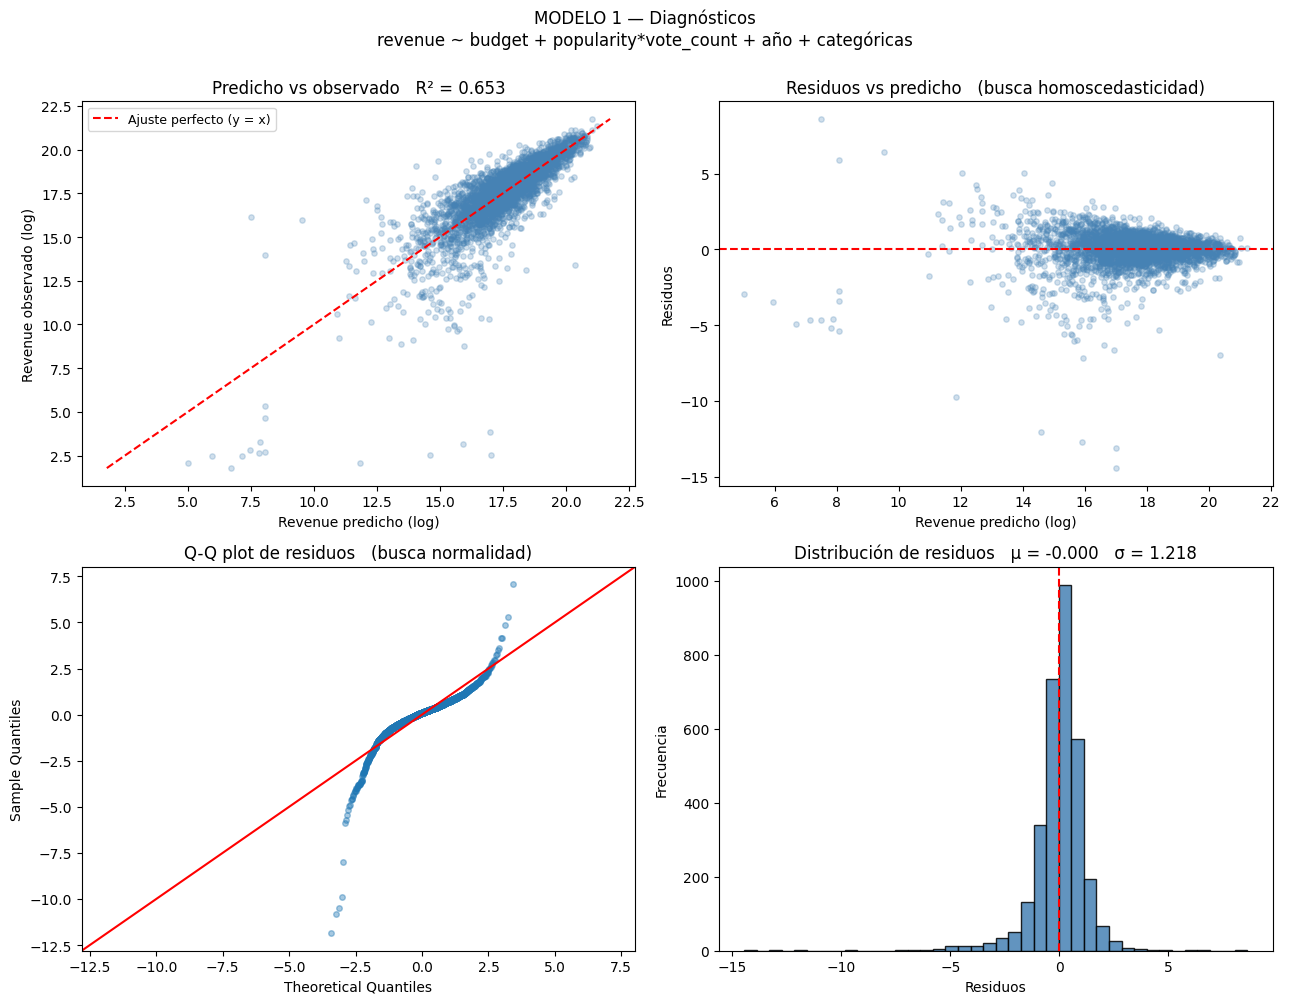

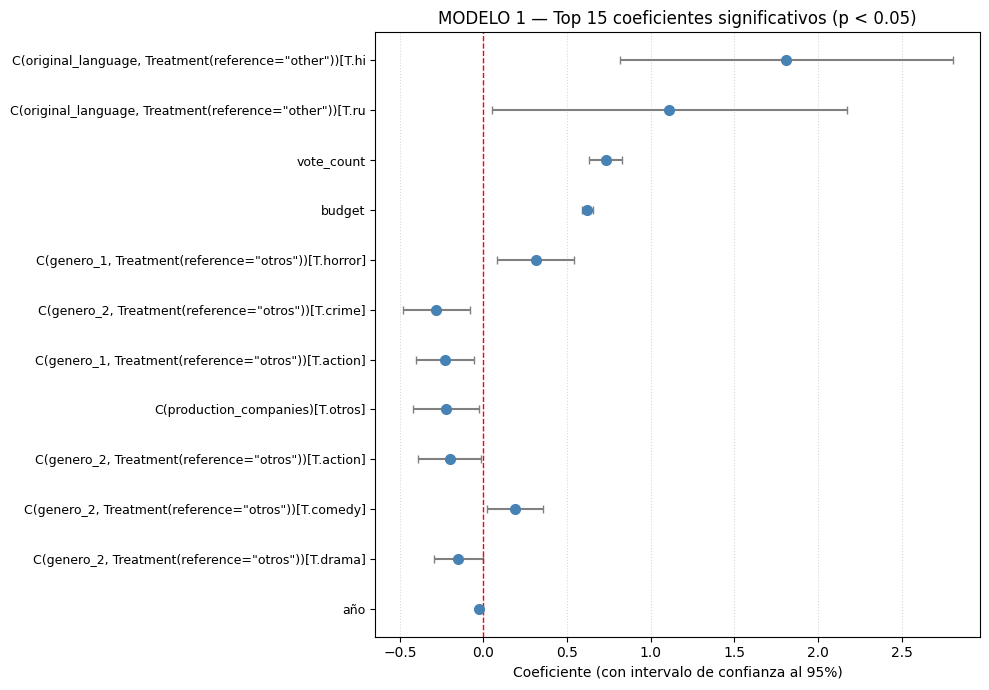

In [136]:
# === Diagnóstico visual del MODELO 1 (celda 22) ===
y_pred = modelo.fittedvalues
y_obs  = pd.Series(modelo.model.endog, index=y_pred.index)
resid  = modelo.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.scatter(y_pred, y_obs, alpha=0.25, s=15, color="steelblue")
lims = [min(y_pred.min(), y_obs.min()), max(y_pred.max(), y_obs.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Ajuste perfecto (y = x)")
ax.set_xlabel("Revenue predicho (log)")
ax.set_ylabel("Revenue observado (log)")
ax.set_title(f"Predicho vs observado   R² = {modelo.rsquared:.3f}")
ax.legend(loc="upper left", fontsize=9)

ax = axes[0, 1]
ax.scatter(y_pred, resid, alpha=0.25, s=15, color="steelblue")
ax.axhline(0, color="r", linestyle="--", linewidth=1.5)
ax.set_xlabel("Revenue predicho (log)")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs predicho   (busca homoscedasticidad)")

ax = axes[1, 0]
sm.qqplot(resid, line="45", fit=True, ax=ax, alpha=0.4, markersize=4)
ax.set_title("Q-Q plot de residuos   (busca normalidad)")

ax = axes[1, 1]
ax.hist(resid, bins=40, edgecolor="black", alpha=0.85, color="steelblue")
ax.axvline(0, color="r", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residuos")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución de residuos   μ = {resid.mean():.3f}   σ = {resid.std():.3f}")

plt.suptitle("MODELO 1 — Diagnósticos\nrevenue ~ budget + popularity*vote_count + año + categóricas",
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

params = modelo.params
pvals  = modelo.pvalues
conf   = modelo.conf_int()
conf.columns = ["lo", "hi"]

mask = (pvals < 0.05) & (params.index != "Intercept")
data = pd.DataFrame({
    "coef": params[mask],
    "lo":   conf.loc[mask, "lo"],
    "hi":   conf.loc[mask, "hi"],
    "pval": pvals[mask],
})
data = data.reindex(data["coef"].abs().sort_values().index).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(data))
ax.errorbar(data["coef"], y,
            xerr=[data["coef"] - data["lo"], data["hi"] - data["coef"]],
            fmt="o", color="steelblue", ecolor="gray", capsize=3, markersize=7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([str(s)[:55] for s in data.index], fontsize=9)
ax.set_xlabel("Coeficiente (con intervalo de confianza al 95%)")
ax.set_title("MODELO 1 — Top 15 coeficientes significativos (p < 0.05)")
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

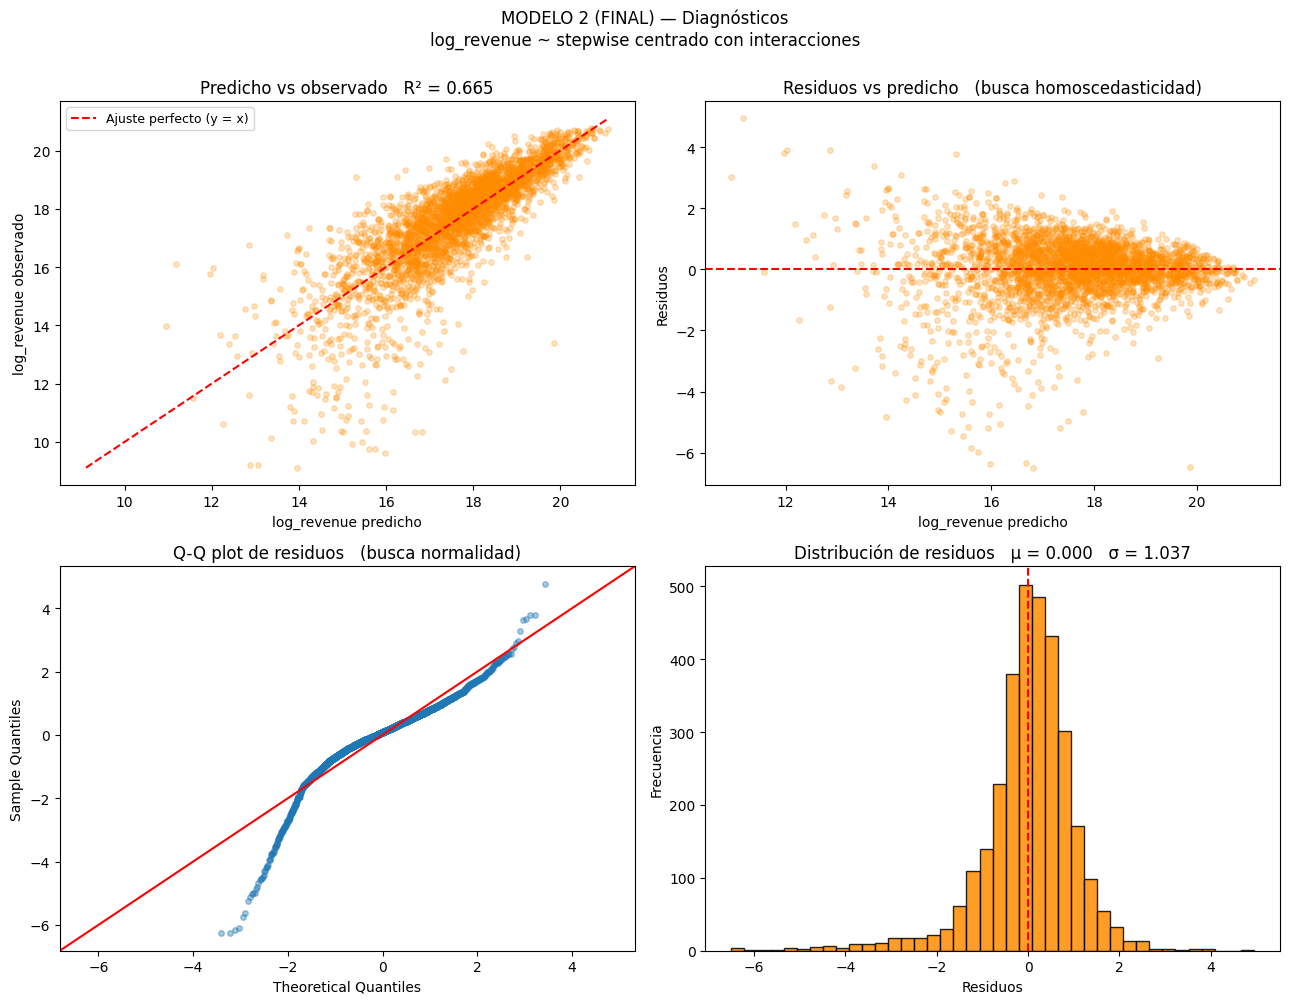

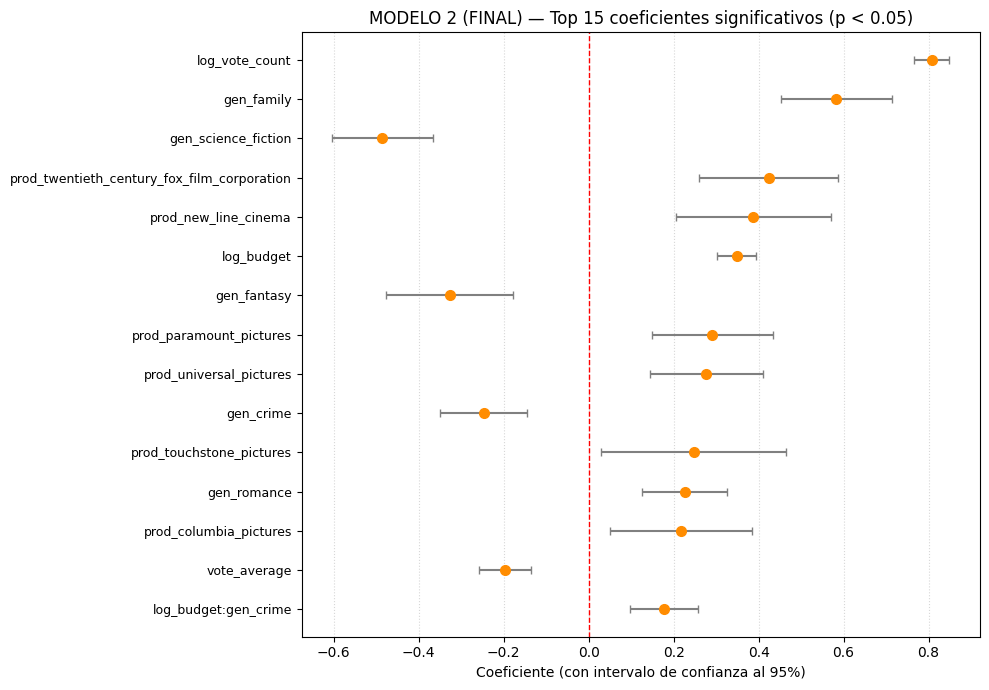


Comparación de los dos modelos
                     R²  R² ajust        AIC        BIC  n_obs  n_params
Modelo 1          0.653     0.649  10513.249  10768.580   3227        41
Modelo 2 (final)  0.665     0.662   9349.522   9531.584   3193        29


In [137]:
# === Diagnóstico visual del MODELO 2 (celda 25, modelo_final sobre df_v2) ===
y_pred2 = modelo_final.fittedvalues
y_obs2  = pd.Series(modelo_final.model.endog, index=y_pred2.index)
resid2  = modelo_final.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.scatter(y_pred2, y_obs2, alpha=0.25, s=15, color="darkorange")
lims = [min(y_pred2.min(), y_obs2.min()), max(y_pred2.max(), y_obs2.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Ajuste perfecto (y = x)")
ax.set_xlabel("log_revenue predicho")
ax.set_ylabel("log_revenue observado")
ax.set_title(f"Predicho vs observado   R² = {modelo_final.rsquared:.3f}")
ax.legend(loc="upper left", fontsize=9)

ax = axes[0, 1]
ax.scatter(y_pred2, resid2, alpha=0.25, s=15, color="darkorange")
ax.axhline(0, color="r", linestyle="--", linewidth=1.5)
ax.set_xlabel("log_revenue predicho")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs predicho   (busca homoscedasticidad)")

ax = axes[1, 0]
sm.qqplot(resid2, line="45", fit=True, ax=ax, alpha=0.4, markersize=4)
ax.set_title("Q-Q plot de residuos   (busca normalidad)")

ax = axes[1, 1]
ax.hist(resid2, bins=40, edgecolor="black", alpha=0.85, color="darkorange")
ax.axvline(0, color="r", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residuos")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución de residuos   μ = {resid2.mean():.3f}   σ = {resid2.std():.3f}")

plt.suptitle("MODELO 2 (FINAL) — Diagnósticos\nlog_revenue ~ stepwise centrado con interacciones",
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

params2 = modelo_final.params
pvals2  = modelo_final.pvalues
conf2   = modelo_final.conf_int()
conf2.columns = ["lo", "hi"]

mask2 = (pvals2 < 0.05) & (params2.index != "Intercept")
data2 = pd.DataFrame({
    "coef": params2[mask2],
    "lo":   conf2.loc[mask2, "lo"],
    "hi":   conf2.loc[mask2, "hi"],
    "pval": pvals2[mask2],
})
data2 = data2.reindex(data2["coef"].abs().sort_values().index).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
y2 = np.arange(len(data2))
ax.errorbar(data2["coef"], y2,
            xerr=[data2["coef"] - data2["lo"], data2["hi"] - data2["coef"]],
            fmt="o", color="darkorange", ecolor="gray", capsize=3, markersize=7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_yticks(y2)
ax.set_yticklabels([str(s)[:55] for s in data2.index], fontsize=9)
ax.set_xlabel("Coeficiente (con intervalo de confianza al 95%)")
ax.set_title("MODELO 2 (FINAL) — Top 15 coeficientes significativos (p < 0.05)")
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Comparación de los dos modelos")
print("=" * 60)
comp = pd.DataFrame({
    "R²":        [modelo.rsquared,     modelo_final.rsquared],
    "R² ajust":  [modelo.rsquared_adj, modelo_final.rsquared_adj],
    "AIC":       [modelo.aic,          modelo_final.aic],
    "BIC":       [modelo.bic,          modelo_final.bic],
    "n_obs":     [int(modelo.nobs),    int(modelo_final.nobs)],
    "n_params":  [int(modelo.df_model), int(modelo_final.df_model)],
}, index=["Modelo 1", "Modelo 2 (final)"]).round(3)
print(comp)